## Importing Libraries

In [2]:
import pandas as pd
pd.options.display.max_columns = None
import numpy as np
import matplotlib.pyplot as plt

## Importing Dataset

In [5]:
big_df = pd.read_csv('../data/movies_big.csv')
big_df = big_df[big_df.big_vote_count > 1]
big_df = big_df[['budget', 'budget_currency', 'cast', 'countries_of_origin',
                'critic_reviews_count', 'big_comments_count', 'big_rate', 'big_vote_count',
                'director', 'genre', 'i_rate', 'i_vote_count_exact', 'id', 'languages',
                'metascore', 'title', 'user_reviews_count', 'writer', 'year']]
little_df = pd.read_csv('../data/movies_little.csv')
little_df = little_df[['id', 'little_comments_count', 'little_rate', 'little_vote_count']]

In [6]:
df = pd.merge(little_df, big_df, on='id', how='inner')

In [7]:
df['little_comments_count'] = df['little_comments_count'].fillna(0)
df['big_comments_count'] = df['big_comments_count'].fillna(0)
df['little_vote_count'] = df['little_vote_count'].fillna(0)
df['big_vote_count'] = df['big_vote_count'].fillna(0)
df['user_reviews_count'] = df['user_reviews_count'].fillna(0)

## Preprocessing Data

In [9]:
from sklearn.preprocessing import StandardScaler

i_sc = StandardScaler()
little_sc = StandardScaler()
big_sc = StandardScaler()

df['i_rate'] = i_sc.fit_transform(df[['i_rate']])
df['little_rate'] = little_sc.fit_transform(df[['little_rate']])
df['big_rate'] = big_sc.fit_transform(df[['big_rate']])

In [10]:
df['i_vote_count_exact'] = df['i_vote_count_exact'].apply(pd.to_numeric)

### Calculating Weighted Ratings (WR)

In [11]:
# Define the minimum number of votes required to be considered (e.g., 1000)
# m_imdb = df['i_vote_count_exact'].quantile(0.5)
# m_little = df['little_vote_count'].quantile(0.75)
# m_big = df['big_vote_count'].quantile(0.9)

def calculate_robust_m(series):
    """Calculate a robust threshold for Bayesian averaging."""
    methods = [
        series.quantile(0.75) + 1.5 * (series.quantile(0.75) - series.quantile(0.25)),  # IQR method
        series.mean() + series.std(),  # Mean + StdDev
        np.percentile(series, 75)  # 75th percentile
    ]
    return np.median(methods)
    
m_imdb = calculate_robust_m(df['i_vote_count_exact'])
m_little = calculate_robust_m(df['little_vote_count'])
m_big = calculate_robust_m(df['big_vote_count'])

# Calculate mean ratings for IMDb and Little Platform
C_imdb = df['i_rate'].mean()
C_little = df['little_rate'].mean()
C_big = df['big_rate'].mean()

# Calculate IMDb weighted rating
df['i_weighted'] = ((df['i_vote_count_exact'] / (df['i_vote_count_exact'] + m_imdb)) * df['i_rate']
                    + (m_imdb / (m_imdb + df['i_vote_count_exact'])) * C_imdb)

# Calculate Little Platform weighted rating
df['little_weighted'] = ((df['little_vote_count'] / (df['little_vote_count'] + m_little)) * df['little_rate']
                    + (m_little / (m_little + df['little_vote_count'])) * C_little)

# Calculate Big Platform weighted rating
df['big_weighted'] = ((df['big_vote_count'] / (df['big_vote_count'] + m_big)) * df['big_rate']
                    + (m_big / (m_big + df['big_vote_count'])) * C_big)


total_votes_little = df['little_vote_count'].sum()
total_votes_big = df['big_vote_count'].sum()
    
# Calculate platform weights based on their relative total votes
little_w = total_votes_little / (total_votes_little + total_votes_big)
big_w = total_votes_big / (total_votes_little + total_votes_big)

df['combined_weighted'] = little_w * df['little_weighted'] + big_w * df['big_weighted']
df['combined_rate'] = little_w * df['little_rate'] + big_w * df['big_rate']
df['combined_vote_count'] = df['big_vote_count'] + df['little_vote_count']

### Currency Conversion to USD

In [12]:
# Create dictionary with currency symbols and their approximate exchange rates to USD
exchange_rates = {
    '$': 1.0,      # USD (base currency)
    '€': 1.08,     # Euro
    '₹': 0.012,    # Indian Rupee
    '£': 1.27,     # British Pound
    'CA$': 0.74,   # Canadian Dollar
    'RUR': 0.011,  # Russian Ruble
    'CN¥': 0.14,   # Chinese Yuan
    '¥': 0.0067,   # Japanese Yen
    'A$': 0.65,    # Australian Dollar
    'NOK': 0.094,  # Norwegian Krone
    'DKK': 0.14,   # Danish Krone
    'FRF': 0.16,   # French Franc (historical)
    'DEM': 0.55,   # Deutsche Mark (historical)
    'R$': 0.20,    # Brazilian Real
    'HK$': 0.13,   # Hong Kong Dollar
    'MYR': 0.21,   # Malaysian Ringgit
    'IDR': 0.000064, # Indonesian Rupiah
    'TRL': 0.031,  # Turkish Lira
    'THB': 0.028,  # Thai Baht
    'CZK': 0.043,  # Czech Koruna
    'IRR': 0.000024, # Iranian Rial
    'ITL': 0.00056, # Italian Lira (historical)
    'FIM': 0.18,   # Finnish Markka (historical)
    'BDT': 0.0091, # Bangladeshi Taka
    'HUF': 0.0028, # Hungarian Forint
    'SEK': 0.096,  # Swedish Krona
    'MX$': 0.059,  # Mexican Peso
    'MVR': 0.065,  # Maldivian Rufiyaa
    'ISK': 0.0073, # Icelandic Króna
    'PLN': 0.25,   # Polish Złoty
    'NT$': 0.032,   # New Taiwan Dollar
    'NZ$': 0.56, # New Zealand Dollar
    'CHF': 1.10, # Swiss Franc
    'ARS': 0.00096, #Argentine Peso
    'ATS': 0.074, # Austrian Schilling
    'ESP': 0.0061, # Spanish Peseta
    'PTE': 0.0051, # Portuguese Escudo
    'EGP': 0.0196, # Egyptian Pound
    'LVL': 1.467 # Latvian Lat
}

# Create DataFrame
exchange_df = pd.DataFrame([
    {'currency_symbol': symbol, 'usd_rate': rate}
    for symbol, rate in exchange_rates.items()
])

# Set currency symbol as index for easier joining
exchange_df.set_index('currency_symbol', inplace=True)

# Display the first few rows
df['budget_exchanged'] = df.apply(lambda x: exchange_df.loc[x.budget_currency, 'usd_rate'] * x.budget if pd.notnull(x.budget) else None, axis=1)

## Analysis

### Top 5 Highest Rated Movies

In [13]:
pd.set_option('display.max_rows', None)

In [14]:
# Get the top 5 movies by IMDb weighted rating
pd.concat((df[['title', 'year','i_rate', 'i_vote_count_exact', 'i_weighted']].sort_values(by='i_weighted', ascending=False, ignore_index=True).head(250), df[['title', 'year','combined_rate', 'combined_vote_count', 'combined_weighted']].sort_values(by='combined_weighted', ascending=False, ignore_index=True).head(250)), axis=1, keys=['imdb', 'Iran'])

imdb                    \
                                                 title    year    i_rate   
0                             The Shawshank Redemption  1994.0  2.714554   
1                                        The Godfather  1972.0  2.617740   
2                                      The Dark Knight  2008.0  2.424113   
3        The Lord of the Rings: The Return of the King  2003.0  2.424113   
4                                         Pulp Fiction  1994.0  2.327299   
5    The Lord of the Rings: The Fellowship of the Ring  2001.0  2.327299   
6                                            Inception  2010.0  2.230486   
7                                     Schindler's List  1993.0  2.424113   
8                                           Fight Club  1999.0  2.230486   
9                                The Godfather Part II  1974.0  2.424113   
10                                        Forrest Gump  1994.0  2.230486   
11               The Lord of the Rings: The Two Towers  2002.0  2.230486   
12                                        Interstellar  2014.0  2.133672   
13                                          The Matrix  1999.0  2.133672   
14                                        12 Angry Men  1957.0  2.424113   
15                                               Se7en  1995.0  2.036858   
16      Star Wars: Episode V - The Empire Strikes Back  1980.0  2.133672   
17                                          Goodfellas  1990.0  2.133672   
18                            The Silence of the Lambs  1991.0  2.036858   
19                                 Saving Private Ryan  1998.0  2.036858   
20                  Star Wars: Episode IV - A New Hope  1977.0  2.036858   
21                                      The Green Mile  1999.0  2.036858   
22                     One Flew Over the Cuckoo's Nest  1975.0  2.133672   
23                                    Django Unchained  2012.0  1.940045   
24                                           Gladiator  2000.0  1.940045   
25                          Terminator 2: Judgment Day  1991.0  2.036858   
26                      The Good, the Bad and the Ugly  1966.0  2.230486   
27                                        The Prestige  2006.0  1.940045   
28                                        The Departed  2006.0  1.940045   
29                               The Dark Knight Rises  2012.0  1.843231   
30                                  Back to the Future  1985.0  1.940045   
31                              Léon: The Professional  1994.0  1.940045   
32                                Inglourious Basterds  2009.0  1.843231   
33                                  American History X  1998.0  1.940045   
34                                       The Lion King  1994.0  1.940045   
35                                  The Usual Suspects  1995.0  1.940045   
36                                             Memento  2000.0  1.843231   
37                                       Spirited Away  2001.0  2.036858   
38                                   Avengers: Endgame  2019.0  1.843231   
39                                            Whiplash  2014.0  1.940045   
40                                            Parasite  2019.0  1.940045   
41                              Avengers: Infinity War  2018.0  1.843231   
42                                               Alien  1979.0  1.940045   
43                                              WALL·E  2008.0  1.843231   
44                                         City of God  2002.0  2.036858   
45                                               Joker  2019.0  1.746417   
46                                    The Intouchables  2011.0  1.940045   
47                                         The Pianist  2002.0  1.940045   
48                                         The Shining  1980.0  1.843231   
49                                   Life Is Beautiful  1997.0  2.036858   
50                             Raiders of the Lost Ark  1981.0  1.843231   
51                    

### Top 5 Most Debated Movies by Users

In [15]:
df['combined_comments'] = df['big_comments_count'] + df['little_comments_count']
pd.concat((df.sort_values(by='user_reviews_count', ascending=False, ignore_index=True)[['title', 'year','user_reviews_count']].head(10)
           , df.sort_values(by='combined_comments', ascending=False, ignore_index=True)[['title', 'year','combined_comments']].head(10)), axis=1, keys=['imdb', 'Iran'])

imdb                             \
                                           title    year user_reviews_count   
0                                          Joker  2019.0            11600.0   
1                       The Shawshank Redemption  1994.0            11400.0   
2                              Avengers: Endgame  2019.0             9500.0   
3                                The Dark Knight  2008.0             8900.0   
4                                     The Batman  2022.0             8200.0   
5                   Zack Snyder's Justice League  2021.0             8100.0   
6  Star Wars: Episode IX - The Rise of Skywalker  2019.0             7800.0   
7                                    Dil Bechara  2020.0             7700.0   
8                                 Captain Marvel  2019.0             7400.0   
9                              Wonder Woman 1984  2020.0             7300.0   

                                Iran                            
                               title    year combined_comments  
0               John Wick: Chapter 4  2023.0            2509.0  
1                             Barbie  2023.0            1574.0  
2                        Oppenheimer  2023.0            1562.0  
3                             Fast X  2023.0            1323.0  
4                           The Menu  2022.0            1160.0  
5         Guy Ritchie's the Covenant  2023.0            1154.0  
6                          The Whale  2022.0            1096.0  
7  Everything Everywhere All at Once  2022.0            1087.0  
8           Avatar: The Way of Water  2022.0             973.0  
9                      Extraction II  2023.0             961.0

### Top 5 Most Debated Movies by Critics

In [16]:
df.sort_values(by='critic_reviews_count', ascending=False).head(10)[['title', 'year','critic_reviews_count', 'user_reviews_count', 'combined_weighted']]

,title,year,critic_reviews_count,user_reviews_count,combined_weighted
1469,The Shape of Water,2017.0,1000.0,1700.0,0.056479
2969,Star Wars: Episode VII - The Force Awakens,2015.0,908.0,4800.0,0.137236
2622,Mad Max: Fury Road,2015.0,832.0,2400.0,0.605314
1769,Gravity,2013.0,802.0,2200.0,0.239797
4989,Batman v Superman: Dawn of Justice,2016.0,799.0,4400.0,-0.164871
4902,Man of Steel,2013.0,785.0,3200.0,0.070289
4899,Arrival,2016.0,762.0,2400.0,0.485804
2713,Wonder Woman,2017.0,741.0,2500.0,0.186282
4223,Star Wars: Episode VIII - The Last Jedi,2017.0,737.0,6900.0,-0.055286
4707,Promising Young Woman,2020.0,732.0,1200.0,-0.192775


### Opinion Differences Between IMDb and Iranians

In [18]:
def categorize_movies(df, high_percentile=0.75, low_percentile=0.25):
    """
    Categorize movies into four groups:
    1. Both liked
    2. Iranian liked but global users didn't
    3. Global users liked but Iranian didn't
    4. Both disliked

    Args:
        df (pd.DataFrame): DataFrame containing movie ratings with columns 'i_weighted' and 'little_weighted'.
        high_percentile (float, optional): Percentile for "liked" threshold. Defaults to 0.75.
        low_percentile (float, optional): Percentile for "disliked" threshold. Defaults to 0.25.

    Returns:
        pd.DataFrame: Original DataFrame with an added 'category' column.
    """
    # Calculate thresholds
    threshold_high_i = df['i_weighted'].quantile(high_percentile)
    threshold_low_i = df['i_weighted'].quantile(low_percentile)
    threshold_high_d = df['combined_weighted'].quantile(high_percentile)
    threshold_low_d = df['combined_weighted'].quantile(low_percentile)
    
    # Define conditions for categories
    conditions = [
        # Both liked
        (df['i_weighted'] >= threshold_high_i) & (df['combined_weighted'] >= threshold_high_d),
        # Iranian liked but global users didn't
        (df['i_weighted'] < threshold_low_i) & (df['combined_weighted'] >= threshold_high_d),
        # Global users liked but Iranian didn't
        (df['i_weighted'] >= threshold_high_i) & (df['combined_weighted'] < threshold_low_d),
        # Both disliked
        (df['i_weighted'] < threshold_low_i) & (df['combined_weighted'] < threshold_low_d)
    ]
    
    # Define category labels
    categories = [
        'Both Liked',
        'Iranian Liked but Global Users Didn\'t',
        'Global Users Liked but Iranian Didn\'t',
        'Both Disliked'
    ]
    
    # Assign categories
    df['category'] = np.select(conditions, categories, default='Neutral')
    df['rating_difference'] = abs(df['i_weighted'] - df['combined_weighted'])
    df['rating_sum'] = df['i_weighted'] + df['combined_weighted']
    
    return df

df_categorized = categorize_movies(df)

#### Stats

In [19]:
# View the count of movies in each category
category_counts = (df_categorized['category'].value_counts() / df_categorized['title'].count()) * 100
print(category_counts)

category
Neutral                                  72.285714
Both Liked                               13.172932
Both Disliked                             8.390977
Iranian Liked but Global Users Didn't     4.090226
Global Users Liked but Iranian Didn't     2.060150
Name: count, dtype: float64


#### Liked by both groups

In [20]:
both_liked_movies = df_categorized[df_categorized['category'] == 'Both Liked']
both_liked_movies[['title', 'year','i_weighted', 'combined_weighted', 'category', 'rating_sum']].sort_values(by='rating_sum', ascending=False).head(10)

,title,year,i_weighted,combined_weighted,category,rating_sum
4265,The Shawshank Redemption,1994.0,2.437227,0.791787,Both Liked,3.229014
4259,The Dark Knight,2008.0,2.174989,0.909257,Both Liked,3.084247
4270,The Godfather,1972.0,2.250759,0.619078,Both Liked,2.869836
4547,The Lord of the Rings: The Return of the King,2003.0,2.078526,0.763022,Both Liked,2.841548
4542,The Lord of the Rings: The Fellowship of the Ring,2001.0,1.999584,0.827675,Both Liked,2.827259
2768,Interstellar,2014.0,1.852802,0.792951,Both Liked,2.645753
4545,The Lord of the Rings: The Two Towers,2002.0,1.883269,0.730092,Both Liked,2.613360
2752,Forrest Gump,1994.0,1.947331,0.638182,Both Liked,2.585513
4272,Schindler's List,1993.0,1.975560,0.596787,Both Liked,2.572347
2756,Fight Club,1999.0,1.955242,0.593864,Both Liked,2.549106


#### Liked by Iranian users but disliked by IMDb users

In [21]:
# View movies in a specific category
both_liked_movies = df_categorized[df_categorized['category'] == 'Iranian Liked but Global Users Didn\'t']
both_liked_movies[['title', 'year','i_weighted', 'combined_weighted', 'category', 'rating_difference']].sort_values(by='rating_difference', ascending=False).head(12)

,title,year,i_weighted,combined_weighted,category,rating_difference
4888,The Twilight Saga: New Moon,2009.0,-0.778864,0.152839,Iranian Liked but Global Users Didn't,0.931704
4887,Twilight,2008.0,-0.688982,0.203958,Iranian Liked but Global Users Didn't,0.892940
2201,The Twilight Saga: Breaking Dawn - Part 1,2011.0,-0.669699,0.195391,Iranian Liked but Global Users Didn't,0.865090
2203,The Twilight Saga: Eclipse,2010.0,-0.594728,0.252928,Iranian Liked but Global Users Didn't,0.847656
5034,Ghost Rider,2007.0,-0.499787,0.303479,Iranian Liked but Global Users Didn't,0.803266
1670,Grown Ups 2,2013.0,-0.362116,0.316120,Iranian Liked but Global Users Didn't,0.678236
2206,The Twilight Saga: Breaking Dawn - Part 2,2012.0,-0.383003,0.270689,Iranian Liked but Global Users Didn't,0.653692
3541,The Hangover Part III,2013.0,-0.338978,0.310542,Iranian Liked but Global Users Didn't,0.649520
776,Pathaan,2023.0,-0.215419,0.427407,Iranian Liked but Global Users Didn't,0.642827
2503,Lucy,2014.0,-0.057467,0.573819,Iranian Liked but Global Users Didn't,0.631286


#### Liked by IMDb users but disliked by Iranian users

In [22]:
# View movies in a specific category
both_liked_movies = df_categorized[df_categorized['category'] == 'Global Users Liked but Iranian Didn\'t']
both_liked_movies[['title', 'year','i_weighted', 'combined_weighted', 'category', 'rating_difference', 'combined_vote_count']].sort_values(by='rating_difference', ascending=False).head(12)

,title,year,i_weighted,combined_weighted,category,rating_difference,combined_vote_count
6183,Barbie,2023.0,0.186076,-1.606107,Global Users Liked but Iranian Didn't,1.792183,2056
781,Everything Everywhere All at Once,2022.0,0.787891,-0.913055,Global Users Liked but Iranian Didn't,1.700946,586
4793,American Beauty,1999.0,1.369635,-0.178824,Global Users Liked but Iranian Didn't,1.548459,122
1778,Get Out,2017.0,0.865818,-0.526172,Global Users Liked but Iranian Didn't,1.391991,215
2570,Snatch,2000.0,1.209218,-0.061628,Global Users Liked but Iranian Didn't,1.270846,62
6526,Challengers,2024.0,0.161577,-1.067841,Global Users Liked but Iranian Didn't,1.229418,123
4830,Monty Python and the Holy Grail,1975.0,1.041280,-0.072067,Global Users Liked but Iranian Didn't,1.113346,8
4091,Midsommar,2019.0,0.327899,-0.743462,Global Users Liked but Iranian Didn't,1.071361,127
2140,Death Proof,2007.0,0.236904,-0.750693,Global Users Liked but Iranian Didn't,0.987598,63
964,Elvis,2022.0,0.326886,-0.638827,Global Users Liked but Iranian Didn't,0.965713,653


#### Disliked by both groups

In [23]:
# View movies in a specific category
both_liked_movies = df_categorized[df_categorized['category'] == 'Both Disliked']
both_liked_movies[['title', 'year', 'i_weighted', 'combined_weighted', 'category', 'rating_sum', 'combined_vote_count']].sort_values(by='rating_sum', ascending=True).head(10)

,title,year,i_weighted,combined_weighted,category,rating_sum,combined_vote_count
6427,Madame Web,2024.0,-0.529795,-1.351984,Both Disliked,-1.881779,201
5983,Winnie-the-Pooh: Blood and Honey,2023.0,-0.303997,-1.566712,Both Disliked,-1.870709,252
6635,Joker: Folie à Deux,2024.0,-0.366750,-1.454641,Both Disliked,-1.821392,245
1564,Batman & Robin,1997.0,-1.163579,-0.608747,Both Disliked,-1.772326,22
362,The Marvels,2023.0,-0.283993,-1.470953,Both Disliked,-1.754946,270
46,Hellboy: The Crooked Man,2024.0,-0.055186,-1.270298,Both Disliked,-1.325485,88
6194,No One Will Save You,2023.0,-0.033191,-1.241017,Both Disliked,-1.274208,127
52,The Platform 2,2024.0,-0.136195,-1.081676,Both Disliked,-1.217871,254
6204,Slotherhouse,2023.0,-0.026129,-1.126040,Both Disliked,-1.152169,71
6157,Meg 2: The Trench,2023.0,-0.301041,-0.829600,Both Disliked,-1.130641,414


### Top 5 Directors to Watch

In [24]:
def analyze_directors(df, role='director'):
    """
    Analyze directors' performance across different rating systems with improved robustness.
    
    Args:
        df (pd.DataFrame): DataFrame containing movie data
        role (str, optional): Column name for directors. Defaults to 'director'.
    
    Returns:
        pd.DataFrame: Comprehensive director performance statistics
    """
    # Input validation
    required_columns = ['id', 'title', 'i_weighted', 'combined_weighted']
    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")
    
    # Handle Multiple Directors with more robust splitting
    df_directors = df.copy()
    
    # More sophisticated director splitting
    def split_directors(directors):
        if pd.isna(directors):
            return []
        # Split by comma, but handle potential quoted names or complex cases
        return [d.strip() for d in directors.replace('"', '').split(',')]
    
    df_directors[role] = df_directors[role].apply(split_directors)
    df_directors = df_directors.explode(role)
    
    # Remove empty director entries
    df_directors = df_directors[df_directors[role].notna() & (df_directors[role] != '')]
    
    # Group by director with more comprehensive aggregation
    director_stats = df_directors.groupby(role).agg(
        movie_count=('id', 'count'),
        # Use set to remove duplicates, then join
        movie_titles=('title', lambda x: ', '.join(sorted(set(x)))),
        i_mean_rating=('i_weighted', 'mean'),
        i_rating_std=('i_weighted', 'std'),
        combined_mean_rating=('combined_weighted', 'mean'),
        combined_rating_std=('combined_weighted', 'std')
    ).reset_index()
    
    # More sophisticated m calculation using multiple statistical methods
    def calculate_robust_m(series):
        """Calculate a robust threshold for Bayesian averaging."""
        methods = [
            series.quantile(0.75) + 1.5 * (series.quantile(0.75) - series.quantile(0.25)),  # IQR method
            series.mean() + series.std(),  # Mean + StdDev
            np.percentile(series, 75)  # 75th percentile
        ]
        return np.median(methods)
    
    m = calculate_robust_m(director_stats['movie_count'])
    
    # More robust overall mean calculation
    C_imdb = df_directors['i_weighted'].mean()  # Using median to reduce outlier impact
    C_combined = df_directors['combined_weighted'].mean()
    
    # Bayesian average with more nuanced weighting
    director_stats['final_i_score'] = (
        (director_stats['movie_count'] / (director_stats['movie_count'] + m)) * director_stats['i_mean_rating'] +
        (m / (director_stats['movie_count'] + m)) * C_imdb
    )
    
    director_stats['final_ad_score'] = (
        (director_stats['movie_count'] / (director_stats['movie_count'] + m)) * director_stats['combined_mean_rating'] +
        (m / (director_stats['movie_count'] + m)) * C_combined
    )
    
    
    
    return director_stats

In [25]:
pd.concat((analyze_directors(df, 'director').sort_values(by = 'final_i_score', ascending=False).head(10).reset_index()[['director', 'movie_titles']], analyze_directors(df, 'director').sort_values(by = 'final_ad_score', ascending=False).head(10).reset_index()[['director', 'movie_titles']]), axis=1, keys=['imdb', 'Iran'])

imdb                                                     \
            director                                       movie_titles   
0  Christopher Nolan  Batman Begins, Dunkirk, Following, Inception, ...   
1  Quentin Tarantino  Death Proof, Django Unchained, Grindhouse, Ing...   
2        Lee Unkrich  Coco, Finding Nemo, Monsters, Inc., Toy Story ...   
3      James Cameron  Aliens, Avatar, Avatar: The Way of Water, Term...   
4    Stanley Kubrick  2001: A Space Odyssey, A Clockwork Orange, Bar...   
5     Frank Darabont  The Green Mile, The Majestic, The Mist, The Sh...   
6        Pete Docter               Inside Out, Monsters, Inc., Soul, Up   
7   Denis Villeneuve  Arrival, Blade Runner 2049, Dune: Part One, Du...   
8      Peter Jackson  Dead Alive, Heavenly Creatures, King Kong, The...   
9       Sergio Leone  A Fistful of Dollars, For a Few Dollars More, ...   

                Iran                                                     
            director                                       movie_titles  
0  Christopher Nolan  Batman Begins, Dunkirk, Following, Inception, ...  
1      Peter Jackson  Dead Alive, Heavenly Creatures, King Kong, The...  
2         Mel Gibson  Apocalypto, Braveheart, Hacksaw Ridge, The Pas...  
3      James Cameron  Aliens, Avatar, Avatar: The Way of Water, Term...  
4        Pete Docter               Inside Out, Monsters, Inc., Soul, Up  
5     Hayao Miyazaki  Castle in the Sky, Howl's Moving Castle, Kiki'...  
6      Chris Sanders  How to Train Your Dragon, Lilo & Stitch, The C...  
7        Kemp Powers          Soul, Spider-Man: Across the Spider-Verse  
8        David Yates  Fantastic Beasts and Where to Find Them, Fanta...  
9       Sam Hargrave                          Extraction, Extraction II

### Top 5 Writers to Watch

In [26]:
pd.concat((analyze_directors(df, 'writer').sort_values(by = 'final_i_score', ascending=False).head(10).reset_index()[['writer', 'movie_titles']], analyze_directors(df, 'writer').sort_values(by = 'final_ad_score', ascending=False).head(10).reset_index()[['writer', 'movie_titles']]), axis=1, keys=['imdb', 'Iran'])

imdb                                                     \
                 writer                                       movie_titles   
0        Jonathan Nolan  Interstellar, Memento, The Dark Knight, The Da...   
1     Christopher Nolan  Batman Begins, Dunkirk, Following, Inception, ...   
2        J.R.R. Tolkien  The Lord of the Rings: The Fellowship of the R...   
3     Quentin Tarantino  Death Proof, Django Unchained, From Dusk Till ...   
4            Mario Puzo  Superman, The Godfather, The Godfather Part II...   
5           Pete Docter  Carl's Date, Inside Out, Monsters, Inc., Soul,...   
6       Philippa Boyens  King Kong, Mortal Engines, The Hobbit: An Unex...   
7       Stanley Kubrick  2001: A Space Odyssey, A Clockwork Orange, Bar...   
8  Francis Ford Coppola  Apocalypse Now, The Conversation, The Godfathe...   
9            Fran Walsh  Dead Alive, Heavenly Creatures, King Kong, Mor...   

                Iran                                                     
              writer                                       movie_titles  
0     Jonathan Nolan  Interstellar, Memento, The Dark Knight, The Da...  
1  Christopher Nolan  Batman Begins, Dunkirk, Following, Inception, ...  
2     J.R.R. Tolkien  The Lord of the Rings: The Fellowship of the R...  
3    Philippa Boyens  King Kong, Mortal Engines, The Hobbit: An Unex...  
4       J.K. Rowling  Fantastic Beasts and Where to Find Them, Fanta...  
5       Steve Kloves  Fantastic Beasts: The Secrets of Dumbledore, H...  
6         Fran Walsh  Dead Alive, Heavenly Creatures, King Kong, Mor...  
7        Pete Docter  Carl's Date, Inside Out, Monsters, Inc., Soul,...  
8      James Cameron  Aliens, Alita: Battle Angel, Avatar, Avatar: T...  
9        T.S. Nowlin  Maze Runner: The Death Cure, Maze Runner: The ...

### Top 5 Actors to Watch

In [27]:
import pandas as pd
import numpy as np

def analyze_performers(df, role='cast', weight_decay=0.9, min_threshold=1):
    """
    Analyze performers' performance (e.g., actors, actresses) based on weighted contributions to movies.
    
    Args:
        df (pd.DataFrame): DataFrame containing movie data
        role (str, optional): Column name for performers (e.g., 'cast'). Defaults to 'cast'.
        weight_decay (float, optional): Decay factor for weight by cast order. Defaults to 0.9.
        min_threshold (int, optional): Minimum number of movies for performer to be included. Defaults to 5.
    
    Returns:
        pd.DataFrame: Comprehensive performer performance statistics
    """
    # Input validation
    required_columns = ['id', 'title', 'i_weighted', 'combined_weighted', role]
    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")
    
    # Handle Multiple Performers
    df_performers = df.copy()

    def split_cast(cast):
        """Split cast list into individual names and assign position-based weights."""
        if pd.isna(cast):
            return []
        # Split cast into names and assign weights
        cast_list = [name.strip() for name in cast.split(',')]
        return [(name, weight_decay ** idx) for idx, name in enumerate(cast_list)]
    
    # Split cast into performer-weight pairs
    df_performers[role] = df_performers[role].apply(split_cast)
    
    # Explode performers into individual rows
    df_performers = df_performers.explode(role)
    df_performers[[role, 'weight']] = pd.DataFrame(df_performers[role].tolist(), index=df_performers.index)
    
    # Remove rows with missing performer names
    df_performers = df_performers[df_performers[role].notna() & (df_performers[role] != '')]
    
    # Normalize the weights by the total weight for each movie (to handle co-stars)
    df_performers['weight'] /= df_performers.groupby('id')['weight'].transform('sum')

    # Calculate weighted ratings
    df_performers['i_weighted_contrib'] = df_performers['i_weighted'] * df_performers['weight']
    df_performers['combined_weighted_contrib'] = df_performers['combined_weighted'] * df_performers['weight']
    
    # Group by performer
    performer_stats = df_performers.groupby(role).agg(
        movie_count=('id', 'count'),
        movie_titles=('title', lambda x: ', '.join(sorted(set(x)))),
        i_sum_rating=('i_weighted_contrib', 'sum'),
        combined_sum_rating=('combined_weighted_contrib', 'sum'),
        total_weight=('weight', 'sum')
    ).reset_index()

    # Apply the minimum movie count threshold
    performer_stats = performer_stats[performer_stats['movie_count'] >= min_threshold]

    # Calculate dynamic m using IQR
    def calculate_robust_m(series):
        """Calculate a robust threshold for Bayesian averaging."""
        methods = [
            series.quantile(0.75) + 1.5 * (series.quantile(0.75) - series.quantile(0.25)),  # IQR method
            series.mean() + series.std(),  # Mean + StdDev
            np.percentile(series, 75)  # 75th percentile
        ]
        return np.median(methods)
    
    m = calculate_robust_m(performer_stats['movie_count'])
    
    # Overall mean ratings
    C_imdb = df_performers['i_weighted_contrib'].mean()
    C_combined = df_performers['combined_weighted_contrib'].mean()
    
    # Calculate Bayesian average with weighted contributions
    performer_stats['final_i_score'] = (
        (performer_stats['movie_count'] / (performer_stats['movie_count'] + m)) * performer_stats['i_sum_rating'] +
        (m / (performer_stats['movie_count'] + m)) * C_imdb
    )
    
    performer_stats['final_ad_score'] = (
        (performer_stats['movie_count'] / (performer_stats['movie_count'] + m)) * performer_stats['combined_sum_rating'] +
        (m / (performer_stats['movie_count'] + m)) * C_combined
    )
    
    # Normalize final scores
    performer_stats['final_i_score'] = (performer_stats['final_i_score'] - performer_stats['final_i_score'].mean()) / performer_stats['final_i_score'].std()
    performer_stats['final_ad_score'] = (performer_stats['final_ad_score'] - performer_stats['final_ad_score'].mean()) / performer_stats['final_ad_score'].std()
        
    return performer_stats

In [28]:
top_cast_stats = analyze_performers(df, role='cast', weight_decay=0.9, min_threshold=1)

# Display top 10 ranked actors/actresses
pd.concat((top_cast_stats.sort_values(by = 'final_i_score', ascending=False).head(70).reset_index()[['cast', 'movie_titles']], top_cast_stats.sort_values(by = 'final_ad_score', ascending=False).head(70).reset_index()[['cast', 'movie_titles']]), axis=1, keys=['imdb', 'Iran'])

imdb                                                     \
                      cast                                       movie_titles   
0                Tom Hanks  A Beautiful Day in the Neighborhood, A Hologra...   
1                Brad Pitt  12 Monkeys, 12 Years a Slave, Ad Astra, Allied...   
2           Robert De Niro  A Bronx Tale, About My Father, Amsterdam, Anal...   
3        Leonardo DiCaprio  Adele: One Night Only, Blood Diamond, Body of ...   
4               Matt Damon  Air, Behind the Candelabra, Contagion, Courage...   
5           Christian Bale  3:10 to Yuma, American Hustle, American Psycho...   
6                Al Pacino  88 Minutes, And Justice for All, Carlito's Way...   
7        Robert Downey Jr.  A Scanner Darkly, Avengers: Age of Ultron, Ave...   
8            Harrison Ford  Air Force One, Anchorman 2: The Legend Continu...   
9               Tom Cruise  A Few Good Men, American Made, Born on the Fou...   
10      Scarlett Johansson  Asteroid City, Avengers: Age of Ultron, Avenge...   
11          Morgan Freeman  57 Seconds, A Good Person, Alpha, Angel Has Fa...   
12       Samuel L. Jackson  1408, A Time to Kill, An Audience with Adele, ...   
13            Mark Ruffalo  13 Going on 30, All the King's Men, Avengers: ...   
14            Ian McKellen  Beauty and the Beast, Flushed Away, Stardust, ...   
15            Bruce Willis  12 Monkeys, 16 Blocks, A Good Day to Die Hard,...   
16            Willem Dafoe  American Psycho, Aquaman, At Eternity's Gate, ...   
17             Johnny Depp  A Nightmare on Elm Street, Alice Through the L...   
18             Gary Oldman  A Christmas Carol, Air Force One, Batman Begin...   
19           Edward Norton  25th Hour, American History X, Asteroid City, ...   
20         Jake Gyllenhaal  Ambulance, Brokeback Mountain, Brothers, Demol...   
21           Ralph Fiennes  Clash of the Titans, Dolittle, Great Expectati...   
22            Hugh Jackman  Australia, Bad Education, Chappie, Deadpool & ...   
23            Kevin Spacey  21, A Bug's Life, A Time to Kill, American Bea...   
24          Cate Blanchett  Babel, Blue Jasmine, Borderlands, Carol, Cinde...   
25           Michael Caine  Batman Begins, Best Sellers, Cars 2, Children ...   
26           Russell Crowe  3:10 to Yuma, A Beautiful Mind, A Good Year, A...   
27               Tom Hardy  Bronson, Capone, Child 44, Dunkirk, Inception,...   
28           Orlando Bloom  Billie Eilish: The World's a Little Blurry, Gr...   
29          Clint Eastwood  A Fistful of Dollars, Cry Macho, Dirty Harry, ...   
30             Elijah Wood  9, Back to the Future Part II, Bookworm, Deep ...   
31       Denzel Washington  2 Guns, American Gangster, Courage Under Fire,...   
32          Jack Nicholson  A Few Good Men, About Schmidt, Anger Managemen...   
33         Viggo Mortensen  A Dangerous Method, A History of Violence, App...   
34            Ryan Gosling  Barbie, Blade Runner 2049, Blue Valentine, Cra...   
35             Emma Watson  Beauty and the Beast, Colonia, Harry Potter 20...   
36             Chris Evans  Avengers: Age of Ultron, Avengers: Endgame, Av...   
37        Daniel Radcliffe  Escape from Pretoria, Guns Akimbo, Harry Potte...   
38    Benedict Cumberbatch  Atonement, August: Osage County, Avengers: End...   
39         Chris Hemsworth  12 Strong, Avengers: Age of Ultron, Avengers: ...   
40           Jeremy Renner  28 Weeks Later, American Hustle, Arrival, Aven...   
41               Ed Harris  A Beautiful Mind, A History of Violence, Apoll...   
42           Robert Duvall  Apocalypse Now, Deep Impact, Falling Down, Gon...   
43  Philip Seymour Hoffman  25th Hour, A Most Wanted Man, Almost Famous, A...   
44        Sigourney Weaver  1492: Conquest of Paradise, A Monster Calls, A...   
45             Ethan Hawke  24 Hours to Live, Adopt a Highway, Before Midn...   
46          Bradley Cooper  10 Cloverfield Lane, A Star Is Born, Aloha, Am...   
47             Bill Murray  Aloha, Ant-Man and the Wa

### Top genres

In [29]:
import pandas as pd
import numpy as np

def analyze_genre(df, weight_decay=0.9):
    """
    Analyze performers' performance (e.g., actors, actresses) based on weighted contributions to movies.
    
    Args:
        df (pd.DataFrame): DataFrame containing movie data
        role (str, optional): Column name for performers (e.g., 'cast'). Defaults to 'cast'.
        weight_decay (float, optional): Decay factor for weight by cast order. Defaults to 0.9.
        min_threshold (int, optional): Minimum number of movies for performer to be included. Defaults to 5.
    
    Returns:
        pd.DataFrame: Comprehensive performer performance statistics
    """
    # Input validation
    required_columns = ['id', 'title', 'i_weighted', 'combined_weighted', 'genre']
    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Missing required column: {col}")
    
    # Handle Multiple Performers
    df_genre = df.copy()

    def split_genre(genres):
        """Split cast list into individual names and assign position-based weights."""
        if pd.isna(genres):
            return []
        # Split cast into names and assign weights
        genre_list = [genre.strip() for genre in genres.split(',')]
        return [(genre, weight_decay ** idx) for idx, genre in enumerate(genre_list)]
    
    # Split cast into performer-weight pairs
    df_genre['genre'] = df_genre['genre'].apply(split_genre)
    
    # Explode performers into individual rows
    df_genre = df_genre.explode('genre')
    df_genre[['genre', 'weight']] = pd.DataFrame(df_genre['genre'].tolist(), index=df_genre.index)
    
    # Remove rows with missing performer names
    df_genre = df_genre[df_genre['genre'].notna() & (df_genre['genre'] != '')]
    
    # Normalize the weights by the total weight for each movie (to handle co-stars)
    df_genre['weight'] /= df_genre.groupby('id')['weight'].transform('sum')

    # Calculate weighted ratings
    df_genre['i_weighted_contrib'] = df_genre['i_weighted'] * df_genre['weight']
    df_genre['combined_weighted_contrib'] = df_genre['combined_weighted'] * df_genre['weight']
    
    # Group by performer
    genre_stats = df_genre.groupby('genre').agg(
        movie_count=('id', 'count'),
        movie_titles=('title', lambda x: ', '.join(sorted(set(x)))),
        i_sum_rating=('i_weighted_contrib', 'mean'),
        combined_sum_rating=('combined_weighted_contrib', 'mean'),
        total_weight=('weight', 'mean')
    ).reset_index()


    # Calculate dynamic m using IQR
    def calculate_robust_m(series):
        """Calculate a robust threshold for Bayesian averaging."""
        methods = [
            series.quantile(0.75) + 1.5 * (series.quantile(0.75) - series.quantile(0.25)),  # IQR method
            series.mean() + series.std(),  # Mean + StdDev
            np.percentile(series, 75)  # 75th percentile
        ]
        return np.median(methods)
    
    m = calculate_robust_m(genre_stats['movie_count'])
    
    # Overall mean ratings
    C_imdb = df_genre['i_weighted_contrib'].mean()
    C_combined = df_genre['combined_weighted_contrib'].mean()
    
    # Calculate Bayesian average with weighted contributions
    genre_stats['final_i_score'] = (
        (genre_stats['movie_count'] / (genre_stats['movie_count'] + m)) * genre_stats['i_sum_rating'] +
        (m / (genre_stats['movie_count'] + m)) * C_imdb
    )
    
    genre_stats['final_ad_score'] = (
        (genre_stats['movie_count'] / (genre_stats['movie_count'] + m)) * genre_stats['combined_sum_rating'] +
        (m / (genre_stats['movie_count'] + m)) * C_combined
    )
    
    # Normalize final scores
    genre_stats['final_i_score'] = (genre_stats['final_i_score'] - genre_stats['final_i_score'].mean()) / genre_stats['final_i_score'].std()
    genre_stats['final_ad_score'] = (genre_stats['final_ad_score'] - genre_stats['final_ad_score'].mean()) / genre_stats['final_ad_score'].std()
        
    return genre_stats

In [30]:
top_cast_stats = analyze_genre(df, weight_decay=0.9)

# Display top 10 ranked genres
pd.concat((top_cast_stats.sort_values(by = 'final_i_score', ascending=False).head(70).reset_index()[['genre', 'movie_titles']], top_cast_stats.sort_values(by = 'final_ad_score', ascending=False).head(70).reset_index()[['genre', 'movie_titles']]), axis=1, keys=['imdb', 'Iran'])

imdb                                                     \
          genre                                       movie_titles   
0         Drama  #Alive, 10 Cloverfield Lane, 10 Days of a Good...   
1     Biography  12 Years a Slave, 127 Hours, 12th Fail, 1492: ...   
2         Crime  10 Days of a Good Man, 12 Angry Men, 14 Camera...   
3           War  1917, 20 Days in Mariupol, A Journal for Jorda...   
4     Animation  100% Wolf, 22 vs. Earth, 5 Centimeters per Sec...   
5     Adventure  100% Wolf, 13 Assassins, 14 Peaks: Nothing Is ...   
6       Western  3:10 to Yuma, A Fistful of Dollars, A Million ...   
7     Film-Noir  Ace in the Hole, Dark Passage, Detective Story...   
8         Sport  14 Peaks: Nothing Is Impossible, A League of T...   
9       Musical  8 Women, A Week Away, Ae Dil Hai Mushkil, Anne...   
10       Sci-Fi  10 Cloverfield Lane, 12 Monkeys, 1984, 2001: A...   
11        Music  8 Mile, A Beautiful Life, A Cinderella Story: ...   
12  Documentary  14 Peaks: Nothing Is Impossible, 20 Days in Ma...   
13      History  12 Strong, 12 Years a Slave, 12.12: The Day, 1...   
14        Short  22 vs. Earth, Bao, Bilby, Carl's Date, Ciao Al...   
15       Family  16 Wishes, 2:Hrs, 5 Centimeters per Second, 8-...   
16      Romance  10 Things I Hate About You, 10 Years, 13 Going...   
17      Fantasy  13 Going on 30, 1408, 16 Wishes, 17 Again, 47 ...   
18      Mystery  10 Days of a Good Man, 10x10, 12 Monkeys, 1408...   
19       Comedy  10 Things I Hate About You, 10 Years, 100 Thin...   
20       Action  #Alive, 12 Strong, 12.12: The Day, 13 Assassin...   
21     Thriller  10x10, 12 Feet Deep, 12 Monkeys, 13 Sins, 14 C...   
22       Horror  #Alive, 10 Cloverfield Lane, 12 Feet Deep, 13 ...   

           Iran                                                     
          genre                                       movie_titles  
0     Animation  100% Wolf, 22 vs. Earth, 5 Centimeters per Sec...  
1     Adventure  100% Wolf, 13 Assassins, 14 Peaks: Nothing Is ...  
2     Biography  12 Years a Slave, 127 Hours, 12th Fail, 1492: ...  
3         Drama  #Alive, 10 Cloverfield Lane, 10 Days of a Good...  
4         Crime  10 Days of a Good Man, 12 Angry Men, 14 Camera...  
5        Action  #Alive, 12 Strong, 12.12: The Day, 13 Assassin...  
6        Family  16 Wishes, 2:Hrs, 5 Centimeters per Second, 8-...  
7         Sport  14 Peaks: Nothing Is Impossible, A League of T...  
8   Documentary  14 Peaks: Nothing Is Impossible, 20 Days in Ma...  
9         Music  8 Mile, A Beautiful Life, A Cinderella Story: ...  
10      Romance  10 Things I Hate About You, 10 Years, 13 Going...  
11          War  1917, 20 Days in Mariupol, A Journal for Jorda...  
12      Western  3:10 to Yuma, A Fistful of Dollars, A Million ...  
13    Film-Noir  Ace in the Hole, Dark Passage, Detective Story...  
14        Short  22 vs. Earth, Bao, Bilby, Carl's Date, Ciao Al...  
15      Fantasy  13 Going on 30, 1408, 16 Wishes, 17 Again, 47 ...  
16      History  12 Strong, 12 Years a Slave, 12.12: The Day, 1...  
17      Musical  8 Women, A Week Away, Ae Dil Hai Mushkil, Anne...  
18       Sci-Fi  10 Cloverfield Lane, 12 Monkeys, 1984, 2001: A...  
19       Comedy  10 Things I Hate About You, 10 Years, 100 Thin...  
20      Mystery  10 Days of a Good Man, 10x10, 12 Monkeys, 1408...  
21     Thriller  10x10, 12 Feet Deep, 12 Monkeys, 13 Sins, 14 C...  
22       Horror  #Alive, 10 Cloverfield Lane, 12 Feet Deep, 13 ...

### Influence of Budget on Ratings

In [31]:
def analyze_budget_vs_ratings(df):
    """
    Analyze the influence of movie budgets on IMDb and Little Platform ratings.
    """
    import seaborn as sns

    # Filter out entries with missing or zero budget
    df_budget = df[df['budget_exchanged'].notna() & (df['budget_exchanged'] > 0)].copy()
    
    bins = [0, 8e6, 2.4e7, 4.5e7, 7.5e7, 4.149e8]
    labels = ['Very Low', 'Low', 'Medium', 'High', 'Blockbuster']
    df_budget['budget_range'] = pd.cut(df_budget['budget_exchanged'], bins=bins, labels=labels, right=False)

    budget_stats = df_budget.groupby('budget_range').agg(
        movie_count=('id', 'count'),
        avg_imdb_rating=('i_rate', 'mean'),
        std_imdb_rating=('i_rate', 'std'),
        avg_iran_rating=('combined_rate', 'mean'),
        std_iran_rating=('combined_rate', 'std'),
        avg_rating_difference=('rating_difference', 'mean')
    ).reset_index()

    melted_data = budget_stats.melt(
        id_vars='budget_range', 
        value_vars=['avg_imdb_rating', 'avg_iran_rating'], 
        var_name='Platform', 
        value_name='Average Rating'
    )

    # Create figure with two y-axes
    fig, ax1 = plt.subplots(figsize=(12, 8))
    ax2 = ax1.twinx()

    # Plot bars on primary y-axis
    sns.barplot(data=melted_data, x='budget_range', y='Average Rating', 
                hue='Platform', ax=ax1)

    # Customize axes
    ax1.set_ylabel('Average Rating')
    
    plt.title('Average Ratings and Across Budget Ranges')
    plt.xticks(rotation=45)

    # Adjust legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.tight_layout()
    plt.show()
    
    return budget_stats

C:\Users\rezam\AppData\Local\Temp\ipykernel_10292\3982641668.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  budget_stats = df_budget.groupby('budget_range').agg(


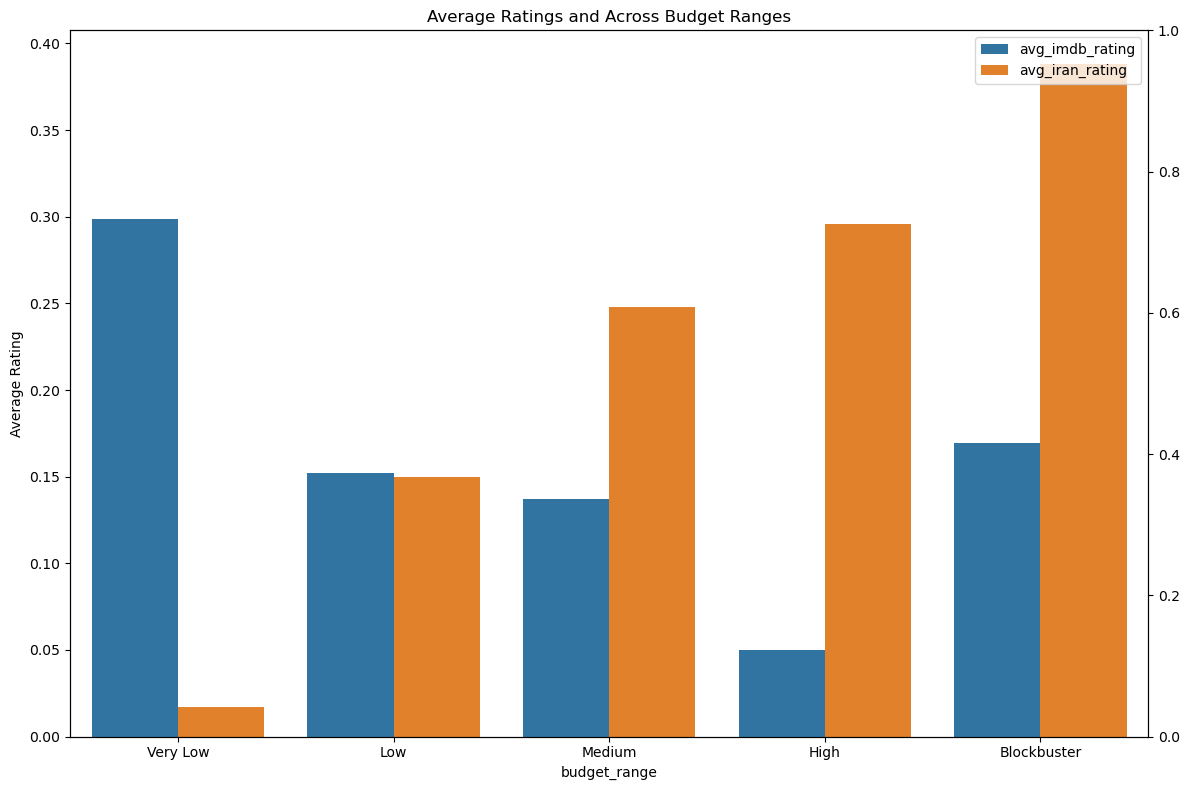

,budget_range,movie_count,avg_imdb_rating,std_imdb_rating,avg_iran_rating,std_iran_rating,avg_rating_difference
0,Very Low,976,0.298477,1.110554,0.017296,0.837284,0.198824
1,Low,982,0.152245,0.976237,0.149669,0.660357,0.204966
2,Medium,757,0.137161,0.814473,0.247786,0.540691,0.199959
3,High,469,0.050216,0.838468,0.295631,0.567749,0.227819
4,Blockbuster,760,0.169628,0.836665,0.388187,0.531351,0.272126


In [32]:
budget_stats = analyze_budget_vs_ratings(df)
budget_stats

### Most popular countries

In [33]:
country_language_mapping = {
    'Algeria': ['Arabic', 'French'],
    'Argentina': ['Spanish'],
    'Australia': ['English'],
    'Austria': ['German'],
    'Bahamas': ['English'],
    'Bangladesh': ['Bengali'],
    'Belgium': ['Dutch', 'French', 'German'],
    'Bhutan': ['Dzongkha'],
    'Bolivia': ['Spanish', 'Quechua'],
    'Bosnia and Herzegovina': ['Bosnian', 'Croatian', 'Serbian'],
    'Brazil': ['Portuguese'],
    'Bulgaria': ['Bulgarian'],
    'Cambodia': ['Central Khmer'],
    'Canada': ['English', 'French'],
    'Chile': ['Spanish'],
    'China': ['Mandarin', 'Cantonese'],
    'Colombia': ['Spanish'],
    'Croatia': ['Croatian'],
    'Czech Republic': ['Czech'],
    'Czechoslovakia': ['Czech', 'Slovak'],
    'Denmark': ['Danish'],
    'Dominican Republic': ['Spanish'],
    'Egypt': ['Arabic'],
    'Estonia': ['Estonian'],
    'Federal Republic of Yugoslavia': ['Serbian', 'Croatian'],
    'Finland': ['Finnish', 'Swedish'],
    'France': ['French'],
    'Georgia': ['Georgian'],
    'Germany': ['German'],
    'Ghana': ['Akan'],
    'Greece': ['Greek'],
    'Guatemala': ['Spanish'],
    'Hong Kong': ['Cantonese'],
    'Hungary': ['Hungarian'],
    'Iceland': ['Icelandic'],
    'India': ['Hindi', 'English', 'Telugu', 'Tamil', 'Kannada', 'Punjabi', 'Gujarati', 'Marathi'],
    'Indonesia': ['Indonesian'],
    'Iran': ['Persian'],
    'Ireland': ['English', 'Irish Gaelic'],
    'Israel': ['Hebrew'],
    'Italy': ['Italian'],
    'Japan': ['Japanese'],
    'Jordan': ['Arabic'],
    'Kazakhstan': ['Kazakh', 'Russian'],
    'Kosovo': ['Albanian', 'Serbian'],
    'Lebanon': ['Arabic', 'French'],
    'Lithuania': ['Lithuanian'],
    'Luxembourg': ['French', 'German', 'Luxembourgish'],
    'Malaysia': ['Malay', 'English'],
    'Malta': ['Maltese', 'English'],
    'Mexico': ['Spanish'],
    'Mongolia': ['Mongolian'],
    'Morocco': ['Arabic', 'French'],
    'Netherlands': ['Dutch'],
    'Nigeria': ['Hausa', 'Yoruba', 'Igbo'],
    'Norway': ['Norwegian'],
    'Occupied Palestinian Territory': ['Arabic'],
    'Pakistan': ['Urdu'],
    'Paraguay': ['Spanish', 'Guarani'],
    'Peru': ['Spanish', 'Quechua'],
    'Philippines': ['Filipino'],
    'Poland': ['Polish'],
    'Portugal': ['Portuguese'],
    'Puerto Rico': ['Spanish'],
    'Qatar': ['Arabic'],
    'Romania': ['Romanian'],
    'Russia': ['Russian'],
    'Saint Kitts and Nevis': ['English'],
    'Saudi Arabia': ['Arabic'],
    'Serbia': ['Serbian'],
    'Singapore': ['English', 'Mandarin', 'Malay', 'Tamil'],
    'South Africa': ['Zulu', 'Xhosa', 'Afrikaans', 'English'],
    'South Korea': ['Korean'],
    'Soviet Union': ['Russian'],
    'Spain': ['Spanish', 'Catalan', 'Basque', 'Galician'],
    'Sweden': ['Swedish'],
    'Switzerland': ['German', 'French', 'Italian', 'Romansh'],
    'Taiwan': ['Mandarin', 'Min Nan'],
    'Thailand': ['Thai'],
    'Tunisia': ['Arabic', 'French'],
    'Turkey': ['Turkish'],
    'Ukraine': ['Ukrainian'],
    'United Arab Emirates': ['Arabic'],
    'United States': ['English'],
    'Uruguay': ['Spanish'],
    'Vietnam': ['Vietnamese'],
    'West Germany': ['German'],
    'Yugoslavia': ['Serbo-Croatian'],
}


In [35]:
def analyze_countries(df, country_language_mapping):
    """Analyze movies by first country of origin with separate IMDb and Little Platform rankings.
    Only includes countries with 5 or more movies."""
    import pandas as pd
    import numpy as np
    
    # Data preparation
    df_countries = df.copy()
    df_countries['countries_of_origin'] = df_countries['countries_of_origin'].str.split(',').str[0].str.strip()
    df_countries['primary_language'] = df_countries['languages'].str.split(',').str[0].str.strip()
    
    # Filter out rows with NaN values
    df_countries = df_countries.dropna(subset=['countries_of_origin', 'primary_language'])
    
    # Language validation
    def validate_language(row):
        country = row['countries_of_origin'].strip()
        language = row['primary_language'].strip()
        if country not in country_language_mapping:
            return False
        valid_languages = country_language_mapping.get(country, [])
        return language in valid_languages
    
    df_countries = df_countries[df_countries.apply(validate_language, axis=1)]
    
    if df_countries.empty:
        print("No valid rows after filtering.")
        return pd.DataFrame(), {}
    
    # Get movie counts per country before main analysis
    country_counts = df_countries['countries_of_origin'].value_counts()
    valid_countries = country_counts[country_counts >= 5].index
    
    # Filter dataframe to only include countries with 5 or more movies
    df_countries = df_countries[df_countries['countries_of_origin'].isin(valid_countries)]
    
    if df_countries.empty:
        print("No countries with 5 or more movies after filtering.")
        return pd.DataFrame(), {}
    
    # Calculate statistics
    countries_stats = df_countries.groupby('countries_of_origin').agg(
        movie_count=('id', 'count'),
        i_mean_rating=('i_weighted', 'mean'),
        i_rating_std=('i_weighted', 'std'),
        combined_mean_rating=('combined_weighted', 'mean'),
        combined_rating_std=('combined_weighted', 'std')
    ).reset_index()
    
    # Get top movies with separate IMDb and Little Platform rankings
    top_movies = {}
    for country in valid_countries:
        country_df = df_countries[df_countries['countries_of_origin'] == country]
        
        # IMDb top movies
        imdb_top = country_df.nlargest(min(10, len(country_df)), 'i_weighted')[
            ['title', 'i_weighted', 'combined_weighted', 'primary_language', 'id', 'year']
        ]
        
        # Little Platform top movies
        iran_top = country_df.nlargest(min(10, len(country_df)), 'combined_weighted')[
            ['title', 'i_weighted', 'combined_weighted', 'primary_language', 'id', 'year']
        ]
        
        top_movies[country] = {
            'imdb': imdb_top.to_dict('records'),
            'iran': iran_top.to_dict('records')
        }
    
    # Bayesian average calculation
    def calculate_bayesian_average(movie_count, mean_rating, C, m):
        if movie_count == 0:
            return C
        return ((movie_count / (movie_count + m)) * mean_rating +
                (m / (movie_count + m)) * C)
    
    def calculate_robust_m(series):
        """Calculate a robust threshold for Bayesian averaging."""
        methods = [
            series.quantile(0.75) + 1.5 * (series.quantile(0.75) - series.quantile(0.25)),  # IQR method
            series.mean() + series.std(),  # Mean + StdDev
            np.percentile(series, 75)  # 75th percentile
        ]
        return np.median(methods)
    
    m = calculate_robust_m(countries_stats['movie_count'])
    
    C_imdb = df_countries['i_weighted'].mean()
    C_combined = df_countries['combined_weighted'].mean()
    
    countries_stats['final_i_score'] = countries_stats.apply(
        lambda x: calculate_bayesian_average(x['movie_count'], x['i_mean_rating'], C_imdb, m), axis=1
    )
    countries_stats['final_ad_score'] = countries_stats.apply(
        lambda x: calculate_bayesian_average(x['movie_count'], x['combined_mean_rating'], C_combined, m), axis=1
    )
    
    return countries_stats, top_movies

In [36]:
top_countries = analyze_countries(df, country_language_mapping)
pd.concat((top_countries[0].sort_values(by='final_i_score', ascending=False).reset_index()[['countries_of_origin', 'movie_count']].head(10), top_countries[0].sort_values(by='final_ad_score', ascending=False).reset_index()[['countries_of_origin', 'movie_count']].head(10)), axis=1, keys=['imdb', 'Iran'])

imdb                            Iran            
  countries_of_origin movie_count countries_of_origin movie_count
0               Italy          41               Japan         191
1               Japan         191         South Korea         192
2       United States        3729               Italy          41
3              Brazil           8                Iran           5
4              Sweden          26       United States        3729
5             Germany          52             Denmark          23
6                Iran           5           Hong Kong          30
7              Mexico          17              Brazil           8
8        Soviet Union           6        Soviet Union           6
9             Denmark          23             Germany          52

In [91]:
pd.DataFrame(top_countries[1]['Iran']['imdb'])

,title,i_weighted,ad_weighted,primary_language,id,year
0,A Separation,0.766779,0.424161,Persian,tt1832382,2011.0
1,Children of Heaven,0.326930,0.294472,Persian,tt0118849,1997.0
2,About Elly,0.199531,0.294538,Persian,tt1360860,2009.0
3,The Salesman,0.189709,0.204375,Persian,tt5186714,2016.0
4,Close-Up,0.110112,0.197774,Persian,tt0100234,1990.0


### Most Popular Years

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def analyze_modern_movies(df):
    imdb_threshold = df['i_vote_count_exact'].quantile(0.25)
    iran_threshold = df['combined_vote_count'].quantile(0.25)
    
    filtered_df = df[
        (df['i_vote_count_exact'] >= imdb_threshold) & 
        (df['combined_vote_count'] >= iran_threshold)
    ]
    
    year_analysis = filtered_df.groupby('year').agg({
        'i_rate': 'mean',
        'combined_rate': 'mean',
        'title': 'count'
    }).reset_index()
    
    year_analysis.columns = ['year', 'avg_i_weighted', 'avg_combined_weighted', 'title_count']
    
    year_analysis = year_analysis.dropna()
    year_analysis['year'] = year_analysis['year'].astype(int)
    
    modern_data = year_analysis[
        (year_analysis['year'] >= 1990) & 
        (year_analysis['year'] <= 2024)
    ]
    
    fig, ax1 = plt.subplots(figsize=(15, 8))
    
    # Plot lines
    line1 = ax1.plot(modern_data['year'], modern_data['avg_i_weighted'], 
                     color='blue', label='IMDb Rating', linewidth=2, marker='o')
    line2 = ax1.plot(modern_data['year'], modern_data['avg_combined_weighted'], 
                     color='red', label='Iran Rating', linewidth=2, marker='o')
    
    # Add ratings labels
    for x, y in zip(modern_data['year'], modern_data['avg_i_weighted']):
        ax1.annotate(f'{y:.2f}', (x, y), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=8)
    for x, y in zip(modern_data['year'], modern_data['avg_combined_weighted']):
        ax1.annotate(f'{y:.2f}', (x, y), textcoords="offset points", 
                    xytext=(0,-15), ha='center', fontsize=8)
    
    # Plot bars with counts
    ax2 = ax1.twinx()
    bars = ax2.bar(modern_data['year'], modern_data['title_count'], 
                   alpha=0.2, color='gray', label='Movie Count')
    
    # Add count labels on bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Rating')
    ax2.set_ylabel('Number of Movies')
    plt.title('Modern Era (1990-2024) Movie Ratings (Filtered by Vote Count)')
    
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    ax1.set_xticks(range(1990, 2025, 2))
    ax1.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    
    top_imdb_years = modern_data.nlargest(3, 'avg_i_weighted')[['year', 'avg_i_weighted', 'title_count']]
    top_iran_years = modern_data.nlargest(3, 'avg_combined_weighted')[['year', 'avg_combined_weighted', 'title_count']]
    
    stats_dict = {
        'rating_correlation': stats.pearsonr(modern_data['avg_i_weighted'], modern_data['avg_combined_weighted'])[0],
        'top_imdb_years': top_imdb_years,
        'top_iran_years': top_iran_years,
        'thresholds': {'imdb': imdb_threshold, 'iran': iran_threshold}
    }
    
    return modern_data, stats_dict, plt.gcf()

def print_analysis(stats):
    print(f"Rating correlation: {stats['rating_correlation']:.3f}")
    print(f"Vote count thresholds - IMDb: {stats['thresholds']['imdb']:.0f}, Little Platform: {stats['thresholds']['iran']:.0f}")
    
    print("\nTop 3 IMDb Years:")
    for _, row in stats['top_imdb_years'].iterrows():
        print(f"{int(row['year'])}: Rating={row['avg_i_weighted']:.2f}, Movies={int(row['title_count'])}")
    
    print("\nTop 3 Little Platform Years:")
    for _, row in stats['top_iran_years'].iterrows():
        print(f"{int(row['year'])}: Rating={row['avg_combined_weighted']:.2f}, Movies={int(row['title_count'])}")

Rating correlation: 0.722
Vote count thresholds - IMDb: 9722, Little Platform: 10

Top 3 IMDb Years:
1994: Rating=0.98, Movies=26
1991: Rating=0.92, Movies=13
1993: Rating=0.89, Movies=29

Top 3 Little Platform Years:
1993: Rating=0.50, Movies=29
1994: Rating=0.48, Movies=26
1990: Rating=0.47, Movies=17


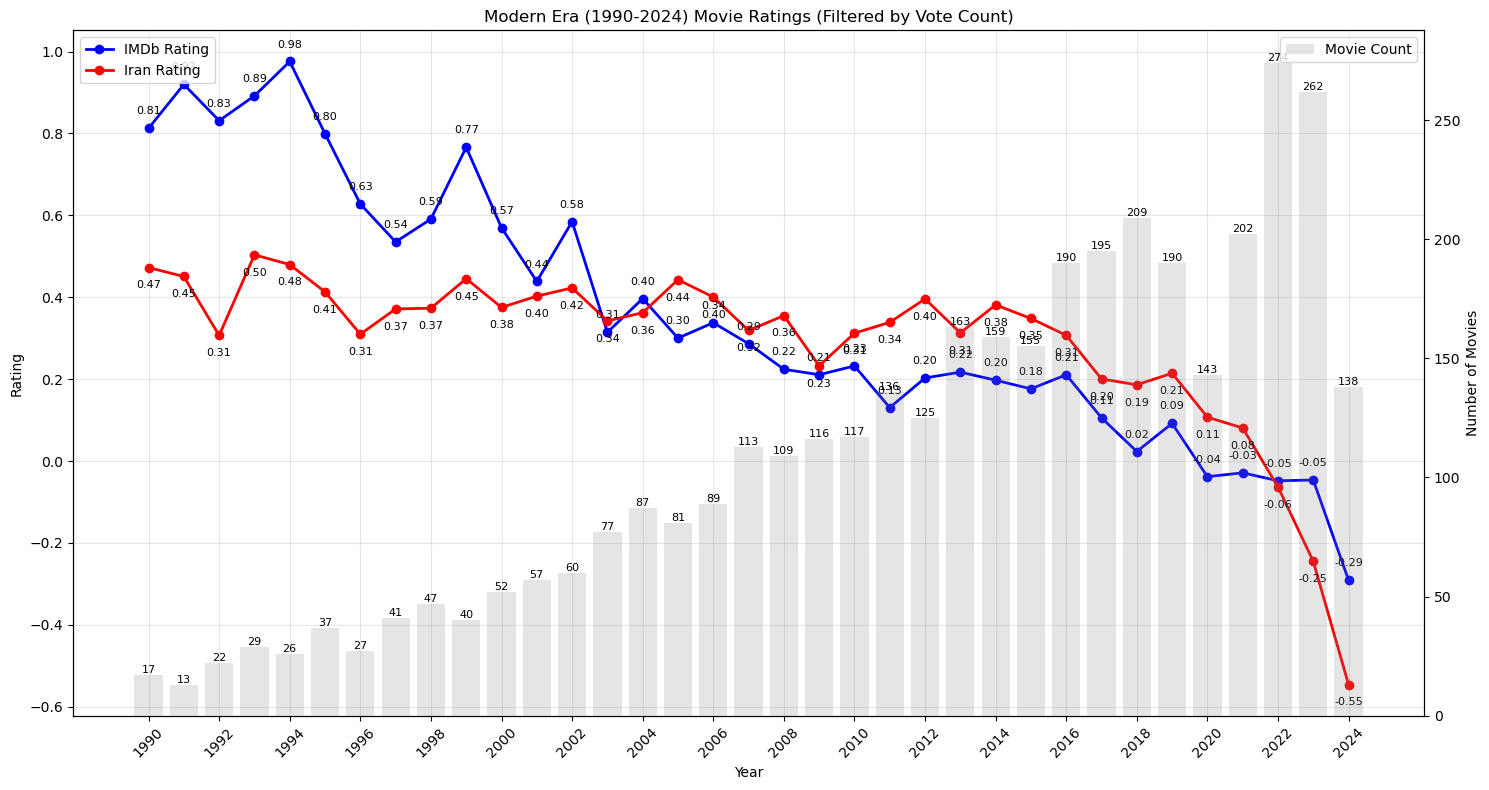

In [38]:
modern_data, stats, fig = analyze_modern_movies(df)
print_analysis(stats)
plt.show()

### Correlation Analysis

In [39]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

def calculate_concordance(df):
    """
    Calculate the concordance between Iranian users' (Little Platform) ratings and IMDb ratings.

    Args:
        df (pd.DataFrame): DataFrame containing 'little_rate' (Little Platform ratings) and 'i_rate' (IMDb ratings).

    Returns:
        dict: A dictionary containing Pearson and Spearman correlation coefficients.
    """
    # Filter out rows with missing ratings
    df_filtered = df[['combined_weighted', 'i_weighted']].dropna()

    # Calculate Pearson correlation
    pearson_corr, pearson_pval = pearsonr(df_filtered['combined_weighted'], df_filtered['i_weighted'])

    # Calculate Spearman correlation
    spearman_corr, spearman_pval = spearmanr(df_filtered['combined_weighted'], df_filtered['i_weighted'])

    # Results
    concordance_results = {
        'Pearson Correlation': pearson_corr,
        'Pearson P-Value': pearson_pval,
        'Spearman Correlation': spearman_corr,
        'Spearman P-Value': spearman_pval
    }

    return concordance_results

# Example usage
concordance_results = calculate_concordance(df)
print("Concordance between Iranian users and IMDb users:")
for metric, value in concordance_results.items():
    print(f"{metric}: {value:.4f}")


Concordance between Iranian users and IMDb users:
Pearson Correlation: 0.4423
Pearson P-Value: 0.0000
Spearman Correlation: 0.4101
Spearman P-Value: 0.0000


In [40]:
import pandas as pd
from scipy import stats
import numpy as np

def analyze_correlations(df):
    # Spearman correlation
    spearman_corr, spearman_p = stats.spearmanr(df['i_weighted'], df['combined_weighted'])
    
    # Kendall's Tau correlation
    kendall_corr, kendall_p = stats.kendalltau(df['i_weighted'], df['combined_weighted'])
    
    results = {
        'Spearman': {
            'correlation': spearman_corr,
            'p_value': spearman_p
        },
        'Kendall': {
            'correlation': kendall_corr,
            'p_value': kendall_p
        }
    }
    
    return pd.DataFrame(results).round(4)

# Run analysis
correlation_results = analyze_correlations(df)
print(correlation_results)

             Spearman  Kendall
correlation    0.4101   0.2866
p_value        0.0000   0.0000


### Correlation Heatmap

<Axes: >

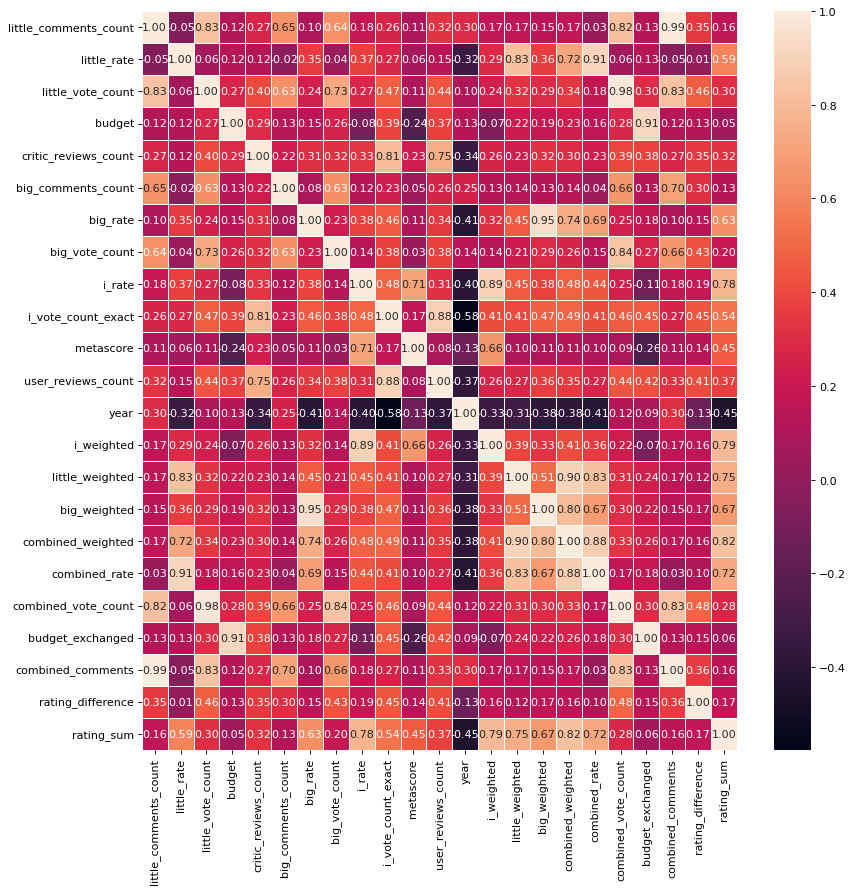

In [41]:
from pandas.api.types import is_numeric_dtype
numeric_cols = []
for col in df.columns:
    if is_numeric_dtype(df[col]):
        numeric_cols.append(col)

import seaborn as sns
from matplotlib.pyplot import figure

figure(figsize=(12, 12), dpi=80)

sns.heatmap(df[numeric_cols].corr(method='spearman'), annot=True, fmt=".2f", linewidth=.5)

### Probability of liking a movie by Iranians given IMDb users have liked it.

In [42]:
import pandas as pd

def calculate_conditional_probability(df, imdb_threshold=0.883784885747889, iran_threshold=0.3683473929766478):
    """
    Calculate the probability that Little Platform users like a movie given IMDb users like the same movie.

    Args:
        df (pd.DataFrame): DataFrame containing 'i_weighted' and 'little_weighted' columns.
        imdb_threshold (float): IMDb liking threshold.
        little_threshold (float): Little Platform liking threshold.

    Returns:
        float: Conditional probability P(Little Platform Liking | IMDb Liking).
    """
    # Define movies liked by IMDb users
    df['imdb_liked'] = df['i_weighted'] > imdb_threshold
    
    # Define movies liked by Little Platform users
    df['iran_liked'] = df['combined_weighted'] > iran_threshold

    # Calculate probabilities
    total_movies = len(df)
    imdb_liked_count = df['imdb_liked'].sum()
    joint_liked_count = df[df['imdb_liked'] & df['iran_liked']].shape[0]

    # Handle edge case: No movies liked by IMDb users
    if imdb_liked_count == 0:
        return 0.0

    # Calculate conditional probability
    conditional_probability = joint_liked_count / imdb_liked_count

    return conditional_probability

# Example usage
conditional_probability = calculate_conditional_probability(df, imdb_threshold=df['i_weighted'].quantile(0.75), iran_threshold=df['combined_weighted'].quantile(0.75))
print(f"P(Little Platform Liking | IMDb Liking) = {conditional_probability:.2f}")


P(Little Platform Liking | IMDb Liking) = 0.53
